# Advanced NLP  Final Project
**BSE Data Science and Decision Making**

**Group Members:** Daniel Campos, Joshua Castillo, Corneel Moons, Tizian Schenk

**Date:** June 2025

**Dataset:** Playlogue v1 - Adult-Child Conversations During Play

**Random Seed:** 20252026

In [ ]:
import random
import numpy as np

SEED = 20252026
random.seed(SEED)
np.random.seed(SEED)

## Part 1: Setting Up the Problem

### 1a. Bibliography and State of the Art

Objective:
The goal of our task is to automatically classify child utterances in parent-child play interactions into one of four speech act categories that was defined by the Dyadic Parent-Child Interaction Coding System (DPICS): Prosocial Talk, Question, Command, and Negative Talk. Each utterance is a single sentence spoken by a child during session where he or she was playing with a parent.

Business Case:
Manual DPICS coding is a time-consuming process that requires trained experts or therapists. In the context of Parent-Child Interaction Therapy (PCIT), therapists need to assess the quality of interactions between parents and children. Automating this process would allow  to get way faster feedback, scale assessments to more families, and potentially enable real-time monitoring during home practice sessions and this would really recude the burden on specialists by a lot.

State of the Art:
Early work on automated DPICS classification used traditional NLP methods. Huber et al. built a system called SpecialTime using TF-IDF features and a linear SVM, achieving around 78% accuracy on 8 parent classes. More recently, fine-tuning RoBERTa on DPICS data outperformed other methods for sentence-level classification. The Playlogue paper itself benchmarked GPT-4 on the dataset, achieving 77.70% accuracy on the 8-class parent task and 87.35% on the 4-class child task, which will be our direct benchmark to beat.

### 1b. Dataset Description

In [3]:
import pandas as pd
import glob

path = r"C:\Users\corne\.cache\huggingface\hub\datasets--playlogue--playlogue-v1\snapshots\fe2d2d1298075f4d15c964e5bb45534eecf6e683\data\dpics_labels"

all_files = glob.glob(path + "/*.csv")
df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

print(df.shape)
print(df.head())

(8764, 5)
                                  sentence speaker    final_rating rating1  \
0  are we gonna play with the potato head?     MOT        Question     NaN   
1                                    yeah.     CHI  Prosocial Talk     NaN   
2                                 i think.     CHI  Prosocial Talk     NaN   
3   do you think we can put them together?     MOT        Question     NaN   
4                                    yeah.     CHI  Prosocial Talk     NaN   

  rating2  
0     NaN  
1     NaN  
2     NaN  
3     NaN  
4     NaN  


We first filter the dataset to only contain the chil utterances 

In [4]:
df_child = df[df['speaker'] == 'CHI'].copy()
df_child = df_child[['sentence', 'final_rating']].reset_index(drop=True)
print(df_child.shape)

(3933, 2)


In [5]:
print("Shape:", df_child.shape)
print("\nColumns:", df_child.columns.tolist())
print("\nData types:\n", df_child.dtypes)
print("\nMissing values:\n", df_child.isna().sum())
print("\nDuplicates:", df_child.duplicated().sum())
print("\nSample utterances:")
print(df_child.head(10))

Shape: (3933, 2)

Columns: ['sentence', 'final_rating']

Data types:
 sentence        str
final_rating    str
dtype: object

Missing values:
 sentence         0
final_rating    38
dtype: int64

Duplicates: 1318

Sample utterances:
                     sentence    final_rating
0                       yeah.  Prosocial Talk
1                    i think.  Prosocial Talk
2                       yeah.  Prosocial Talk
3                         oh.  Prosocial Talk
4  th there is a lot of them.  Prosocial Talk
5           i can't put this.  Prosocial Talk
6     uh this ms potato head.  Prosocial Talk
7         look what i put in.         Command
8                it's a hand.  Prosocial Talk
9               it goes here.  Prosocial Talk


We notice the difference between the 3895 hugging face mentioned on their site and 3933, this is due to the fact of 38 missing labels. We also clearly see the high amount of duplicates present which is worth some extra investigating  

In [6]:
print(df_child[df_child.duplicated(keep=False)].sort_values('sentence').head(20))

     sentence    final_rating
11          .  Prosocial Talk
38          .  Prosocial Talk
155         .  Prosocial Talk
158         .  Prosocial Talk
161         .  Prosocial Talk
176         .  Prosocial Talk
187         .  Prosocial Talk
254         .  Prosocial Talk
291         .  Prosocial Talk
325         .  Prosocial Talk
934         .  Prosocial Talk
981         .  Prosocial Talk
1033        .  Prosocial Talk
1038        .  Prosocial Talk
1068        .  Prosocial Talk
1070        .  Prosocial Talk
1087        .  Prosocial Talk
1089        .  Prosocial Talk
1110        .  Prosocial Talk
1115        .  Prosocial Talk


In [7]:
print("Rows with just a dot:", (df_child['sentence'] == '.').sum())

print("\nMost common sentences:")
print(df_child['sentence'].value_counts().head(10))

Rows with just a dot: 81

Most common sentences:
sentence
yeah.     299
no.       139
xxx.      120
.          81
oh.        49
okay.      35
there.     27
mhm.       27
what?      23
uhhuh.     21
Name: count, dtype: int64


The duplicates are actually really interesting, it seems to be just sentences like "yeah." that a lot of children just have repeated. 'xxx' is a bit of a weird one though so we leave this one out together with the missing values 

In [8]:
df_child = df_child.dropna(subset=['final_rating'])
df_child = df_child[df_child['sentence'] != 'xxx.'].reset_index(drop=True)
print(df_child.shape)
print(df_child['final_rating'].value_counts())

(3799, 2)
final_rating
Prosocial Talk    2980
Question           556
Command            207
Negative Talk       56
Name: count, dtype: int64


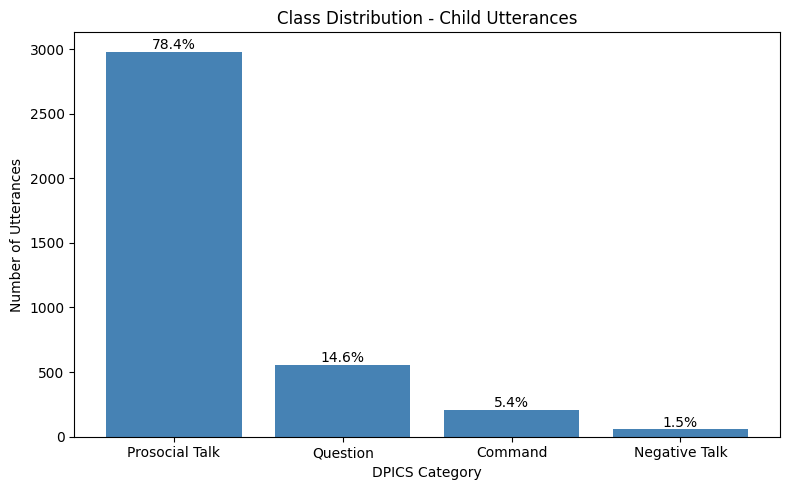

In [9]:
import matplotlib.pyplot as plt

class_counts = df_child['final_rating'].value_counts()
class_pcts = class_counts / len(df_child) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_counts.index, class_counts.values, color='steelblue')

for bar, pct in zip(bars, class_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{pct:.1f}%', ha='center', fontsize=10)

ax.set_title('Class Distribution - Child Utterances')
ax.set_xlabel('DPICS Category')
ax.set_ylabel('Number of Utterances')
plt.tight_layout()
plt.show()

# @generated by Claude (Anthropic) — modified by: [Corneel]

The chart above clearly shows us a strong class imbalance in the dataset. Nearly 4 out of 5 child utterances are labeled as Prosocial Talkwhile Negative Talk accounts for only 1.5% of the data. This imbalance will be an important factor to consider when training and evaluating our models.

In [10]:
df_child['sentence_length'] = df_child['sentence'].str.split().str.len()   

print("Average sentence length (words):", round(df_child['sentence_length'].mean(), 2))
print("Median sentence length (words):", df_child['sentence_length'].median())
print("Shortest utterance:", df_child['sentence_length'].min())
print("Longest utterance:", df_child['sentence_length'].max())
print("\nShortest utterances:")
print(df_child.nsmallest(3, 'sentence_length')[['sentence', 'final_rating']])
print("\nLongest utterances:")
print(df_child.nlargest(3, 'sentence_length')[['sentence', 'final_rating']])

# @generated by Claude (Anthropic) — modified by: [Corneel]

Average sentence length (words): 3.6
Median sentence length (words): 3.0
Shortest utterance: 1
Longest utterance: 23

Shortest utterances:
  sentence    final_rating
0    yeah.  Prosocial Talk
2    yeah.  Prosocial Talk
3      oh.  Prosocial Talk

Longest utterances:
                                               sentence    final_rating
782   i'll put them i'll put one of them up here so ...  Prosocial Talk
2777  first we hafta put how are we xxx now and we n...        Question
3260  let me see if he has green let me see if i wan...  Prosocial Talk


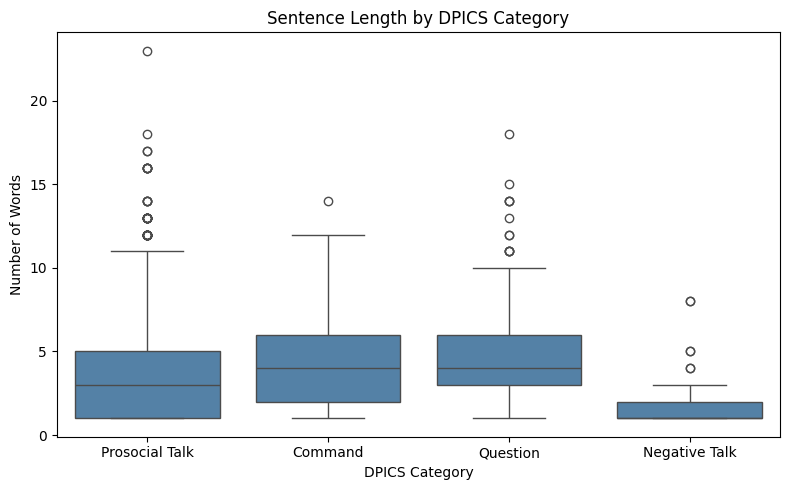

In [11]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_child, x='final_rating', y='sentence_length', color='steelblue')
plt.title('Sentence Length by DPICS Category')
plt.xlabel('DPICS Category')
plt.ylabel('Number of Words')
plt.tight_layout()
plt.show()

# @generated by Claude (Anthropic) — modified by: [Corneel]

In general we see that child utterances are very short, with an average of 3.6 words and a median of just 3 words. 
This is expected given that the dataset focuses on preschool-aged children. Looking at the distribution 
per class, Negative Talk utterances tend to be the shortest, often just one or two words like "no!" or 
"stop it.", while Commands and Questions are slightly longer on average. All categories contain some 
outliers with longer utterances, but these are rare. The short length of utterances in this dataset is 
an important characteristic to keep in mind, as most NLP models are pretrained on much longer and usually adult-type of text.

### 1c. Random Classifier Performance

We decided to follow the evaluation methodology of the original Playlogue paper, so later on and here we evaluate our models 
using accuracy and macro F1 score.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

np.random.seed(SEED)

# Get class probabilities from training data
class_probs = df_child['final_rating'].value_counts(normalize=True)

# Generate random predictions weighted by class frequency
random_preds = np.random.choice(class_probs.index, size=len(df_child), p=class_probs.values)

# Evaluate
acc = accuracy_score(df_child['final_rating'], random_preds)
f1 = f1_score(df_child['final_rating'], random_preds, average='macro')

print(f"Random Classifier Accuracy: {acc:.4f}")
print(f"Random Classifier Macro F1: {f1:.4f}")

# @generated by Claude (Anthropic) — modified by: [Corneel]

Random Classifier Accuracy: 0.6354
Random Classifier Macro F1: 0.2404


Now we see that the weighted random classifier achieves an accuracy of 63.54% and a macro F1 score of 0.24. 
this relatively high accuracy is misleading, as it is largely driven by the frequent random 
prediction of "Prosocial Talk", which is the dominant class. The very low F1 score confirms that the 
random classifier performs poorly across all classes, establishing a low baseline that any 
meaningful model should comfortably be able to exceed.

### 1d. Baseline Implementation

Before we move on to the rules lets first take another look at the type of sentences that are present in each category. 

In [13]:
for label in df_child['final_rating'].unique():
    print(f"\n--- {label} ---")
    print(df_child[df_child['final_rating'] == label]['sentence'].sample(5, random_state=SEED).tolist())


--- Prosocial Talk ---
['no.', 'i gotta put the shoes on first.', 'these are his arms.', 'oh okay.', 'because i looking a orange one.']

--- Command ---
["don't don't forget about.", "now let's look at the animals.", 'only only we we first we hafta take some out.', 'you hafta are supposed to build him.', "don't bother me."]

--- Question ---
['can we put it on?', 'what?', 'and what did i forgot?', "you didn't know a flying shoes right?", 'a visor?']

--- Negative Talk ---
['no.', "ah those um don't go to the fence.", 'no and no.', 'no.', 'no.']


For our rule-based classifier, we decide to use a simple set of handcrafted rules based on keywords and 
punctuation patterns that we just observed in the data. Questions are identified by a question mark at the 
end of the sentence or by common question words such as "what", "where", "why", "how", "can", 
and "do". Negative Talk is detected using a list of negative keywords like "yuck", "stop", and 
"you're wrong". Commands are identified by words like "let's", "hafta", "give me", and "look". 
All remaining utterances are classified as Prosocial Talk, which we thus decide as being the default category. 

In [ ]:
def rule_based_classifier(sentence):
    sentence = sentence.lower().strip()
    
    # Question rules
    question_words = ['what', 'where', 'why', 'how', 'can', 'do', 'did', 'is', 'are', 'who']
    if sentence.endswith('?'):
        return 'Question'
    if any(sentence.startswith(w) for w in question_words):
        return 'Question'
    
    # Negative Talk rules
    negative_keywords = ['yuck', 'stop', "that's not", "you're wrong", 'no and no', 
                         'shut up', 'i hate', 'ugly', "don't like"]
    if any(kw in sentence for kw in negative_keywords):
        return 'Negative Talk'
    
    # Command rules
    command_keywords = ["let's", 'hafta', 'give me', 'look', 'wait', 'come', 
                        'put it', 'you have to', 'we need to']
    if any(kw in sentence for kw in command_keywords):
        return 'Command'
    
    # Default
    return 'Prosocial Talk'

# Apply and evaluate
preds = df_child['sentence'].apply(rule_based_classifier)
acc = accuracy_score(df_child['final_rating'], preds)
f1 = f1_score(df_child['final_rating'], preds, average='macro')

print(f"Rule-based Classifier Accuracy: {acc:.4f}")
print(f"Rule-based Classifier Macro F1: {f1:.4f}")

# @generated by Claude (Anthropic) — modified by: [Corneel]

Rule-based Classifier Accuracy: 0.9118
Rule-based Classifier Macro F1: 0.5944


In [15]:
from sklearn.metrics import classification_report

print(classification_report(df_child['final_rating'], preds))

                precision    recall  f1-score   support

       Command       0.46      0.35      0.40       207
 Negative Talk       0.38      0.05      0.09        56
Prosocial Talk       0.94      0.96      0.95      2980
      Question       0.91      0.97      0.94       556

      accuracy                           0.91      3799
     macro avg       0.67      0.58      0.59      3799
  weighted avg       0.90      0.91      0.90      3799



We see that the rule-based classifier achieves a bery high overall accuracy of 91.18% and a macro 
F1 score of 0.59, even outperforming GPT-4's reported benchmarks on this dataset. However, 
this is largely driven by the strong performance on Prosocial Talk and Question, which together 
make up over 90% of the data and have clear linguistic patterns. The classifier struggles 
significantly with Negative Talk (F1 0.09) and Command (F1 0.40), highlighting the limitations 
of simple keyword matching for more nuanced speech act categories. These results confirm that 
while rule-based approaches can capture obvious patterns, a more sophisticated model will be 
needed to handle the full complexity of the classification task and to be handle the lesser present categories too. 

## Part 2: Data Scientist Challenge

## Part 3: State of the Art Comparison

## Part 4: Model Distillation / Quantization